In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

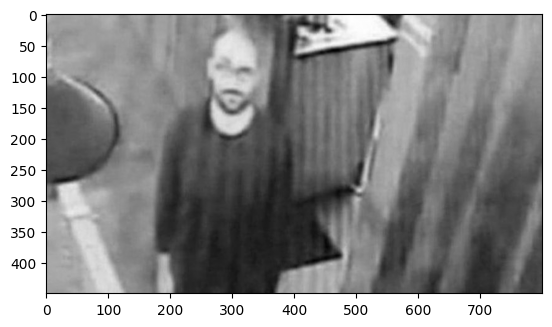

In [34]:
c1 = cv.imread('backup.jpg')
backup = cv.cvtColor(c1, cv.COLOR_BGR2GRAY)
plt.imshow(backup, cmap='gray')
plt.axis('on')
plt.show()

In [4]:
img = cv2.imread('backup.png', 0)

if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan!")

mean3 = cv2.blur(img, (3, 3))
mean9 = cv2.blur(img, (9, 9))

median3 = cv2.medianBlur(img, 3)
median9 = cv2.medianBlur(img, 9)

def mode_filter(image, ksize):
    pad = ksize // 2
    padded = np.pad(image, pad, mode='edge')
    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            area = padded[i:i+ksize, j:j+ksize]

            values, counts = np.unique(area, return_counts=True)
            output[i, j] = values[np.argmax(counts)]

    return output

mode3 = mode_filter(img, 3)
mode9 = mode_filter(img, 9)

kernel_sharp = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(img, -1, kernel_sharp)

smoothed = cv2.GaussianBlur(img, (7, 7), 0)

titles = [
    "Mean Filter (3x3)",
    "Mean Filter (9x9)",
    "Median Filter (3x3)",
    "Median Filter (9x9)",
    "Mode Filter (3x3)",
    "Mode Filter (9x9)",
    "Sharpened Image",
    "Smoothed Image"
]

images = [
    mean3,
    mean9,
    median3,
    median9,
    mode3,
    mode9,
    sharpened,
    smoothed
]

plt.figure(figsize=(14, 7))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'cv2' is not defined

In [6]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape

    # ukuran padding / padding size
    pad = size // 2

    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode="edge")

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case "mean":
            # filter rata-rata / mean filter
            area = size * size

            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # rumus mean manual / manual mean formula
                    # BUAT RUMUS SENDIRI / MAKE YOUR OWN FORMULA

        case "median":
            # filter median / median filter

            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # rumus median manual / manual median formula
                    # BUAT RUMUS SENDIRI / MAKE YOUR OWN FORMULA

        case "modus":
            # filter modus / mode filter

            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # ratakan array / flatten array
                    values = region.ravel()

                    # hitung kemunculan / count occurrences
                    count = {}

                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    # simpan hasil / save result
                    canvas[i, j] = mode_val

    # kembalikan gambar / return image
    return canvas


# cara panggil / how to call
# hasil = filter(foto_karin, 3, "mean")

In [5]:
mean3x3 = convo(img, kernel_3x3)
mean9x9 = convo(img, kernel_9x9)
sharpening = convo(img, kernel_tajam)
smoothing = convo(img, kernel_halus)
modus3x3 = convo_modus_median(img, kernel_3x3_kosong, "modus")
modus9x9 = convo_modus_median(img, kernel_9x9_kosong, "modus")
median3x3 = convo_modus_median(img, kernel_3x3_kosong, "median")
median9x9 = convo_modus_median(img, kernel_9x9_kosong, "median")

NameError: name 'convo' is not defined

In [16]:
def convolution(img, kernel):
    size = kernel.shape[0]

    pad_size = size // 2

    padded = np.pad(img, pad_size, mode='constant')

    canvas = np.zeros_like(img).astype(np.float32)

    height, width = img.shape

    for i in range(height):

        for j in range(width):

            region = padded[i:i+size, j:j+size]

            canvas[i, j] = np.sum(region * kernel)

    return canvas

In [22]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            nilai_pixel = citra_asal[i, j]
            hist_asal[nilai_pixel] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            nilai_pixel = citra_target[i, j]
            hist_target[nilai_pixel] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):                   
        min_diff = float('inf')
        mapping_value = 0
        
        for j in range(256):               
            diff = abs(cdf_asal[i] - cdf_target[j])
            if diff < min_diff:
                min_diff = diff
                mapping_value = j
                
        map_hist[i] = mapping_value

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            nilai_pixel = citra_asal[i, j]
            hasil[i, j] = map_hist[nilai_pixel]

    return hasil

In [24]:
backup = spesifikasi_histogram(windut_gray)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(windah, cmap='gray')
plt.title("Hasil Spesifikasi")
plt.axis('on')

NameError: name 'windut_gray' is not defined

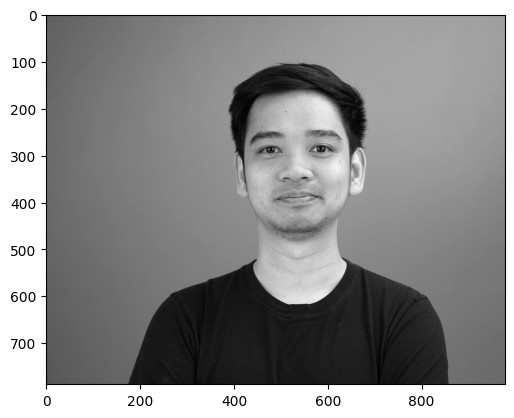

In [36]:
c1 = cv.imread('david.jpg')
backup = cv.cvtColor(c1, cv.COLOR_BGR2GRAY)
plt.imshow(david, cmap='gray')
plt.axis('on')
plt.show()